# Zadanie 4: Obliczenia ewolucyjne 

**Termin realizacji:** 4 maja 2026

**Autorzy:** Jan Rolka, Bartłomiej Mazgaj

## Na 3.0

Do realizacji:

1. Zmodyfikuj przykład "iterative method" z notatnika `tsp_lazy_constraints.ipynb` tak, aby rozwiązywał [problem podróżującego konsumenta](https://en.wikipedia.org/wiki/Traveling_purchaser_problem). Przykładowe problemy generuje poniższa funkcja `generate_random_tpp`. Przyjmij, że wszystkie miasta muszą być odwiedzone niezależnie od tego czy dokonany tam będzie zakup czy też nie. W rozwiązaniu wypisz w którym mieście kupione będą poszczególne przedmioty oraz narysuj trasę.
2. Zmodyfikuj analogicznie kod z notatnika `tsp-genetic.ipynb` tak aby rozwiązywał ten sam problem. Porównaj wydajność (czas obliczeń i wartość funkcji kosztu) dla dziewięciu losowych problemów, po trzy dla rozmiarów (n=50, k=20), (n=50, k=50) oraz (n=100, k=100). Dobierz parametry algorytmu genetycznego tak, aby czas działania nie przekraczał w żadnym przypadku minuty.

## Na 4.0

Do realizacji:

1. Punkty z zadania na 3.0.
2. Dodaj do problemu wagę przedmiotów, powiększającą koszt rozwiązania o długość trasy od miejsca zakupu do końca trasy pomnożoną przez wagę przedmiotu i stały współczynnik dobrany tak, aby dla przedmiotu średniej wagi jego transport między najbardziej odległymi miastami (w linii prostej) wynosił około 1% ceny. Nie dodawaj tego składnika do funkcji kosztu zaimplementowanej w JuMP, ale uwzględnij go w algorytmie genetycznym. Porównaj jakość rozwiązań uzyskanych przez oba algorytmy z uwzględnieniem wagi i bez.
3. Zaimplementuj dodatkowo [krzyżowanie PMX](https://en.wikipedia.org/wiki/Crossover_(genetic_algorithm)#Partially_mapped_crossover_(PMX)) i porównaj wydajność z tym opartym o inwersję permutacji.

## Na 5.0

Do realizacji:

1. Punkty z zadania na 4.0.
2. Zmodyfikuj problem tak, aby konsument nie musiał odwiedzać miast w których niczego nie kupuje.
3. Dodaj dodatkowo do porównania zmodyfikowany dla problemu podróżującego konsumenta przykład "lazy constraints" z notatnika `tsp_lazy_constraints.ipynb`. Dane do problemu powinny być generowane tak, aby konsument w zwracanym rozwiązaniu odwiedzał przynajmniej 3 miasta i omijał przynajmniej 2.

## 1. Konfiguracja środowiska

In [1]:
import Pkg
Pkg.add("GLPK")
Pkg.add(name="Evolutionary", version="0.11.1")
Pkg.add("Printf")
Pkg.add("Plots")

    Updating registry at `C:\Users\X\.julia\registries\General.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\X\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\X\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\X\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\X\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\X\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\X\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\X\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\X\.julia\environments\

In [2]:
using JuMP
import GLPK
using Random
import MathOptInterface as MOI
using Evolutionary
using Printf
using Plots

# Konfiguracja backendu Plots do PNG
ENV["GKSwstype"] = "png"
gr()
default(fmt = :png)

## 2. Generator problemów i funkcje pomocnicze

### Generator TPP

Funkcja `generate_random_tpp(n, k)` generuje:
- `n` miast losowo rozmieszczonych w kwadracie [0,100]²,
- macierz odległości euklidesowych `d[i,j]`,
- macierz kosztów `cost_item_city[item, city]` ∈ Uniform(50, 150).

In [3]:
function generate_random_tpp(n, k; random_seed=1)
    rng = Random.MersenneTwister(random_seed)
    X = 100 * rand(rng, n)
    Y = 100 * rand(rng, n)
    d = [sqrt((X[i]-X[j])^2 + (Y[i]-Y[j])^2) for i in 1:n, j in 1:n]
    cost_item_city = 50.0 .+ 100.0 .* rand(rng, k, n)  # cost[item, city]
    return X, Y, d, cost_item_city
end

generate_random_tpp (generic function with 1 method)

### Funkcje pomocnicze dla subtourów (na podstawie kodu z TSP)

In [4]:
# Zwraca najkrótszy podtour w grafie nieskierowanym zadanym listą krawędzi.
function subtour(edges::Vector{Tuple{Int,Int}}, n)
    shortest_subtour, unvisited = collect(1:n), Set(collect(1:n))
    while !isempty(unvisited)
        this_cycle, neighbors = Int[], unvisited
        while !isempty(neighbors)
            current = pop!(neighbors)
            push!(this_cycle, current)
            if length(this_cycle) > 1
                pop!(unvisited, current)
            end
            neighbors = [j for (i,j) in edges if i == current && j in unvisited]
        end
        if length(this_cycle) < length(shortest_subtour)
            shortest_subtour = this_cycle
        end
    end
    return shortest_subtour
end

function selected_edges(x::Matrix{Float64}, n)
    return Tuple{Int,Int}[(i,j) for i in 1:n, j in 1:n if x[i,j] > 0.5]
end

subtour(x::Matrix{Float64}) = subtour(selected_edges(x, size(x,1)), size(x,1))
subtour(x::AbstractMatrix{VariableRef}) = subtour(JuMP.value.(x))

subtour (generic function with 3 methods)

### Kodowanie inwersyjne permutacji

In [5]:
function perm_to_inv(perm::Vector)
    N = length(perm)
    inv = zeros(Int, N)
    for i in 1:N
        for m in 1:N
            if perm[m] == i
                break
            end
            if perm[m] > i
                inv[i] += 1
            end
        end
    end
    return inv
end

function inv_to_perm(inv::Vector)
    N = length(inv)
    pos = zeros(Int, N)
    for i in N:-1:1
        for m in (i+1):N
            if pos[m] >= inv[i] + 1
                pos[m] += 1
            end
        end
        pos[i] = inv[i] + 1
    end
    perm = zeros(Int, N)
    for i in 1:N
        perm[pos[i]] = i
    end
    return perm
end

# Weryfikacja poprawności kodowania
RP = Random.randperm(20)
@assert RP == inv_to_perm(perm_to_inv(RP)) "Błąd w kodowaniu inwersyjnym!"
println("Kodowanie inwersyjne: OK")

Kodowanie inwersyjne: OK


### Dekodowanie rozwiązania TPP (wszystkie miasta odwiedzane)

In [6]:
# Dla danej permutacji miast oblicza koszt przejazdu i zakupów.
# Każdy przedmiot jest kupowany w najtańszym mieście na trasie.
function decode_tpp(perm::Vector{Int}, d::Matrix{Float64}, cost_item_city::Matrix{Float64})
    n = size(d, 1)
    k = size(cost_item_city, 1)
    travel_cost = sum(d[perm[i], perm[mod1(i+1,n)]] for i in 1:n)
    purchase_cost = 0.0
    items_bought_at = zeros(Int, k)
    for item in 1:k
        best_price = Inf
        best_city  = perm[1]
        for city in perm
            if cost_item_city[item, city] < best_price
                best_price = cost_item_city[item, city]
                best_city  = city
            end
        end
        purchase_cost += best_price
        items_bought_at[item] = best_city
    end
    return perm, travel_cost, purchase_cost, items_bought_at
end

decode_tpp (generic function with 1 method)

### Wizualizacja trasy

In [7]:
function plot_tpp_solution(X, Y, perm, items_bought_at; title_str="TPP – trasa i zakupy")
    n = length(perm)
    items_per_city = zeros(Int, n)
    for city in items_bought_at
        items_per_city[city] += 1
    end
    plt = Plots.plot(title=title_str, legend=false, aspect_ratio=:equal)
    for i in 1:n
        a = perm[i]; b = perm[mod1(i+1,n)]
        Plots.plot!(plt, [X[a],X[b]], [Y[a],Y[b]]; color=:lightblue, lw=1.2)
    end
    for city in 1:n
        cnt = items_per_city[city]
        col = cnt == 0 ? :lightgrey : :steelblue
        sz  = cnt == 0 ? 4 : min(4 + cnt, 12)
        Plots.scatter!(plt, [X[city]], [Y[city]]; color=col, markersize=sz, alpha=0.85)
    end
    Plots.scatter!(plt, [X[perm[1]]], [Y[perm[1]]]; color=:green, markersize=10, markershape=:star5)
    return plt
end

function selected_edges_for_plot(x_val, n)
    return [(i,j) for i in 1:n, j in 1:n if x_val[i,j] > 0.5]
end

selected_edges_for_plot (generic function with 1 method)

## 3. Rozwiązanie na 3.0

### 3.1 ILP – metoda iteracyjna dla TPP (wszystkie miasta odwiedzane)

**Sformułowanie matematyczne:**

Zmienne decyzyjne:
- $x_{ij} \in \{0,1\}$ – czy krawędź $(i,j)$ jest w trasie (macierz symetryczna),
- $p_{item,city} \in \{0,1\}$ – czy przedmiot `item` kupiono w mieście `city`.

Funkcja celu:
$$\min\; \frac{1}{2}\sum_{i,j} d_{ij}\,x_{ij} + \sum_{item,city} c_{item,city}\,p_{item,city}$$

Ograniczenia:
- $\sum_j x_{ij} = 2$ dla każdego $i$ (dokładnie dwie krawędzie na miasto),
- $x_{ii} = 0$ (brak pętli),
- $\sum_{city} p_{item,city} = 1$ dla każdego przedmiotu (kupiony dokładnie raz),
- eliminacja podtourów (dodawana iteracyjnie).

Kluczowa różnica względem TSP: w funkcji celu pojawia się człon zakupowy oraz dodatkowe zmienne $p$.

In [8]:
function build_tpp_model(d, c, n, k)
    model = Model(GLPK.Optimizer)
    set_silent(model)
    @variable(model, x[1:n, 1:n], Bin, Symmetric)
    @variable(model, p[1:k, 1:n], Bin)
    @objective(model, Min, sum(d .* x) / 2 + sum(c .* p))
    @constraint(model, [i in 1:n], sum(x[i,:]) == 2)
    @constraint(model, [i in 1:n], x[i,i] == 0)
    @constraint(model, [item in 1:k], sum(p[item,:]) == 1)  # każdy przedmiot kupiony raz
    return model
end

build_tpp_model (generic function with 1 method)

Demonstracja na problemie n=20, k=8 (dla czytelności wyników).

In [9]:
n_demo, k_demo = 20, 8
X_d, Y_d, d_d, c_d = generate_random_tpp(n_demo, k_demo; random_seed=42)

iterative_model = build_tpp_model(d_d, c_d, n_demo, k_demo)
optimize!(iterative_model)
@assert is_solved_and_feasible(iterative_model)
time_iterated = solve_time(iterative_model)

cycle = subtour(iterative_model[:x])
iter_count = 0
while 1 < length(cycle) < n_demo
    iter_count += 1
    S = [(i,j) for (i,j) in Iterators.product(cycle,cycle) if i < j]
    @constraint(iterative_model,
        sum(iterative_model[:x][i,j] for (i,j) in S) <= length(cycle)-1)
    optimize!(iterative_model)
    @assert is_solved_and_feasible(iterative_model)
    time_iterated += solve_time(iterative_model)
    cycle = subtour(iterative_model[:x])
end

# Rozdziel koszty przejazdu i zakupów z rozwiązania ILP
x_ilp = JuMP.value.(iterative_model[:x])
p_ilp = JuMP.value.(iterative_model[:p])
travel_cost_ilp  = sum(d_d[i,j] * x_ilp[i,j] for i in 1:n_demo, j in 1:n_demo) / 2
purchase_cost_ilp = sum(c_d[m,i] * p_ilp[m,i]
                        for m in 1:k_demo, i in 1:n_demo)

println("\n=== ILP iteracyjny (n=$n_demo, k=$k_demo) ===")
@printf("Koszt przejazdu:           %.2f\n", travel_cost_ilp)
@printf("Koszt zakupów:             %.2f\n", purchase_cost_ilp)
@printf("Koszt całkowity:           %.2f\n", travel_cost_ilp + purchase_cost_ilp)
@printf("Czas obliczeń:             %.3f s\n", time_iterated)
@printf("Liczba iteracji:           %d\n", iter_count)


=== ILP iteracyjny (n=20, k=8) ===
Koszt przejazdu:           354.12
Koszt zakupów:             441.54
Koszt całkowity:           795.66
Czas obliczeń:             0.005 s
Liczba iteracji:           5


In [10]:
p_val = round.(Int, JuMP.value.(iterative_model[:p]))
println("\nZakupy (przedmiot => miasto):")
for item in 1:k_demo
    city = findfirst(p_val[item,:] .== 1)
    @printf("  Przedmiot %2d => miasto %2d (cena: %.2f)\n",
            item, city, c_d[item, city])
end


Zakupy (przedmiot => miasto):
  Przedmiot  1 => miasto  3 (cena: 55.84)
  Przedmiot  2 => miasto 15 (cena: 53.34)
  Przedmiot  3 => miasto  9 (cena: 55.87)
  Przedmiot  4 => miasto 14 (cena: 52.67)
  Przedmiot  5 => miasto  1 (cena: 53.35)
  Przedmiot  6 => miasto  3 (cena: 60.94)
  Przedmiot  7 => miasto 15 (cena: 50.41)
  Przedmiot  8 => miasto 14 (cena: 59.13)


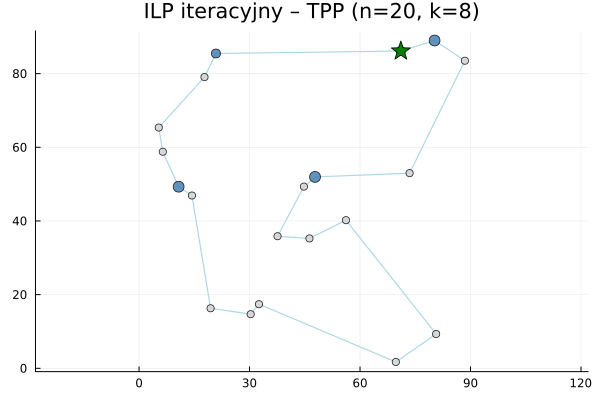

In [11]:
x_ilp = JuMP.value.(iterative_model[:x])
p_val = round.(Int, JuMP.value.(iterative_model[:p]))
p_bought = [findfirst(p_val[item,:] .== 1) for item in 1:k_demo]
perm_ilp = let
    edges = selected_edges(x_ilp, n_demo)
    adj = Dict{Int,Vector{Int}}()
    for (i,j) in edges
        push!(get!(adj,i,Int[]), j)
        push!(get!(adj,j,Int[]), i)
    end
    p = Int[1]; prev = 0; curr = 1
    for _ in 2:n_demo
        nxt = first(filter(v -> v != prev, adj[curr]))
        push!(p, nxt); prev = curr; curr = nxt
    end
    p
end
display(MIME("image/png"), plot_tpp_solution(X_d, Y_d, perm_ilp, p_bought;
    title_str="ILP iteracyjny – TPP (n=$n_demo, k=$k_demo)"))

### 3.2 Algorytm genetyczny dla TPP

#### Parametry algorytmu

| Parametr | Wartość | 
|----------|---------|
| `populationSize` | 400 | 
| `crossoverRate` | 0.9 | 
| `mutationRate` | 0.05 | 
| `epsilon` | 0.01 | 
| `iterations` | 500 | 

In [12]:
# Crossover w przestrzeni inwersji 
function recombine_inv(v1::T, v2::T;
        rng::AbstractRNG=Random.default_rng()) where {T<:AbstractVector}
    N = length(v1)
    i1 = perm_to_inv(v1); i2 = perm_to_inv(v2)
    cp = rand(rng, 2:(N-1))
    c1 = vcat(i1[1:cp], i2[(cp+1):N])
    c2 = vcat(i2[1:cp], i1[(cp+1):N])
    return inv_to_perm(c1), inv_to_perm(c2)
end

# Mutacja swap – zamiana dwóch losowych miast w trasie
function mutate_swap(recombinant::AbstractVector;
        rng::AbstractRNG=Random.default_rng())
    N = length(recombinant)
    i = rand(rng, 1:N); j = rand(rng, 1:N)
    recombinant[i], recombinant[j] = recombinant[j], recombinant[i]
    return recombinant
end

mutate_swap (generic function with 1 method)

In [13]:
# Demonstracja GA na tym samym problemie co ILP
function make_tpp_cost(d, c)
    return (perm::Vector{Int}) -> begin
        _, tv, pv, _ = decode_tpp(perm, d, c)
        tv + pv
    end
end

Random.seed!(42)
tpp_cost_demo = make_tpp_cost(d_d, c_d)
x0_demo = collect(1:n_demo)

t0 = time()
result_ga_demo = Evolutionary.optimize(
    tpp_cost_demo, x0_demo,
    GA(; populationSize=300, crossover=recombine_inv, mutation=mutate_swap,
          epsilon=0.01, crossoverRate=0.9, mutationRate=0.05),
    Evolutionary.Options(; iterations=500)
)
time_ga_demo = time() - t0

_, tv_ga, pv_ga, ibt_ga = decode_tpp(result_ga_demo.minimizer, d_d, c_d)

println("\n=== GA inwersyjny (n=$n_demo, k=$k_demo) ===")
@printf("Koszt przejazdu: %.2f\n", tv_ga)
@printf("Koszt zakupów:   %.2f\n", pv_ga)
@printf("Koszt łączny:    %.2f\n", tv_ga + pv_ga)
@printf("Czas:            %.3f s\n", time_ga_demo)


=== GA inwersyjny (n=20, k=8) ===
Koszt przejazdu: 476.53
Koszt zakupów:   441.54
Koszt łączny:    918.08
Czas:            0.933 s


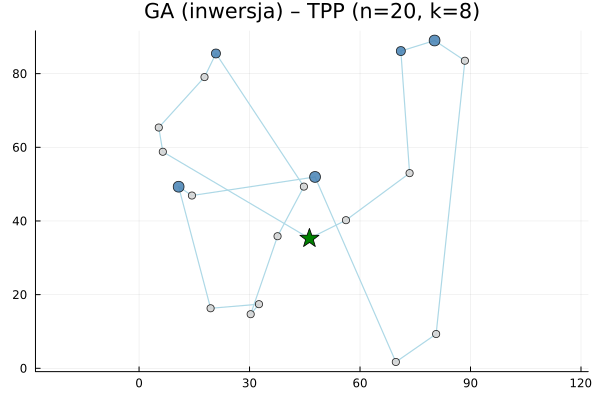

In [14]:
display(MIME("image/png"), plot_tpp_solution(X_d, Y_d, result_ga_demo.minimizer, ibt_ga;
    title_str="GA (inwersja) – TPP (n=$n_demo, k=$k_demo)"))

### 3.3 Porównanie wydajności: 9 losowych problemów

GA vs ILP dla trzech rozmiarów: (n=50,k=20), (n=50,k=50), (n=100,k=100).
Dla każdego rozmiaru – trzy instancje (różne ziarna losowości).

In [29]:
configs_30 = [
    (n=50,  k=20),
    (n=50,  k=50),
    (n=100, k=100),
]
seeds_30 = [1, 2, 3]

GA_POP   = 500
GA_ITERS = 200
ILP_TIME_LIMIT_SEC = 60.0  # limit czasu dla GLPK (1 min)

println("=" ^ 115)
@printf("%-14s|%-6s| %-10s %-10s %-10s %-8s| %-10s %-10s %-10s %-8s| %-7s\n",
        "Konf.", "Ziarno",
        "GA P","GA Z","GA SUM","T_GA[s]",
        "ILP P","ILP Z","ILP SUM","T_ILP[s]",
        "Gap[%]")
println("=" ^ 115)

for cfg in configs_30
    for seed in seeds_30
        n, k = cfg.n, cfg.k
        _, _, d2, c2 = generate_random_tpp(n, k; random_seed=seed)

        # ── GA ──
        Random.seed!(seed)
        cost_fn = make_tpp_cost(d2, c2)
        t0 = time()
        res_ga = Evolutionary.optimize(
            cost_fn, collect(1:n),
            GA(; populationSize=GA_POP, crossover=recombine_inv, mutation=mutate_swap,
                  epsilon=0.01, crossoverRate=0.9, mutationRate=0.05),
            Evolutionary.Options(; iterations=GA_ITERS)
        )
        t_ga = time() - t0
        _, tv_ga2, pv_ga2, _ = decode_tpp(res_ga.minimizer, d2, c2)

        # ── ILP iteracyjny (z limitem czasu) ──
        ilp_m = build_tpp_model(d2, c2, n, k)
        set_time_limit_sec(ilp_m, ILP_TIME_LIMIT_SEC)
        t0 = time()
        optimize!(ilp_m)
        t_ilp = solve_time(ilp_m)

        if is_solved_and_feasible(ilp_m)
            cy = subtour(ilp_m[:x])
            while 1 < length(cy) < n
                S = [(i,j) for (i,j) in Iterators.product(cy,cy) if i < j]
                @constraint(ilp_m, sum(ilp_m[:x][i,j] for (i,j) in S) <= length(cy)-1)
                optimize!(ilp_m)
                t_ilp += solve_time(ilp_m)
                cy = is_solved_and_feasible(ilp_m) ? subtour(ilp_m[:x]) : Int[]
                isempty(cy) && break
            end
        end

        if is_solved_and_feasible(ilp_m)
            xi = JuMP.value.(ilp_m[:x])
            pi = JuMP.value.(ilp_m[:p])
            tv_ilp = sum(d2[i,j]*xi[i,j] for i in 1:n, j in 1:n) / 2
            pv_ilp = sum(c2[m,i]*pi[m,i] for m in 1:k, i in 1:n)
            gap = 100*((tv_ga2+pv_ga2) - (tv_ilp+pv_ilp)) / (tv_ilp+pv_ilp)
            @printf("n=%3d k=%3d |%6d| %10.1f %10.1f %10.1f %8.2f| %10.1f %10.1f %10.1f %8.2f| %+6.2f%%\n",
                    n, k, seed,
                    tv_ga2, pv_ga2, tv_ga2+pv_ga2, t_ga,
                    tv_ilp, pv_ilp, tv_ilp+pv_ilp, t_ilp,
                    gap)
        else
            status_str = termination_status(ilp_m) == MOI.TIME_LIMIT ? "LIMIT" : "BRAK"
            @printf("n=%3d k=%3d |%6d| %10.1f %10.1f %10.1f %8.2f| %10s %10s %10s %8s| %7s\n",
                    n, k, seed,
                    tv_ga2, pv_ga2, tv_ga2+pv_ga2, t_ga,
                    "—", "—", "—", status_str, "N/A")
        end
    end
end
println("=" ^ 115)
println("Gap = (GA - ILP) / ILP * 100%. Wartość dodatnia: GA droższy od optimum.")
println("LIMIT: ILP nie zdążył znaleźć optimum w czasie $(Int(ILP_TIME_LIMIT_SEC))s – wynik suboptymalne.")

Konf.         |Ziarno| GA P       GA Z       GA SUM     T_GA[s] | ILP P      ILP Z      ILP SUM    T_ILP[s]| Gap[%] 
n= 50 k= 20 |     1|     1153.3     1024.2     2177.5     0.29|      545.8     1024.2     1570.0     0.02| +38.70%
n= 50 k= 20 |     2|      954.0     1035.7     1989.7     0.27|      576.3     1035.7     1612.1     0.57| +23.43%
n= 50 k= 20 |     3|     1087.0     1062.8     2149.8     0.23|      616.7     1062.8     1679.5     0.08| +28.00%
n= 50 k= 50 |     1|     1153.3     2573.3     3726.7     0.36|      545.8     2573.3     3119.1     0.03| +19.48%
n= 50 k= 50 |     2|      954.0     2597.6     3551.6     0.42|      576.3     2597.6     3173.9     0.95| +11.90%
n= 50 k= 50 |     3|     1087.0     2619.7     3706.7     0.42|      616.7     2619.7     3236.4     0.11| +14.53%
n=100 k=100 |     1|     2318.9     5076.1     7395.0     1.77|      744.6     5076.1     5820.7   222.17| +27.05%
n=100 k=100 |     2|     2274.6     5103.0     7377.7     1.57|      776.5    

### wyniki GA
|Konf.|Seed |Przejazd |Zakup |Suma |Czas[s] |
|-----|-----|---------|------|-----|----|
|n=50 k=20 |1 |1153.3 |1024.2 |2177.5 |0.29 |
|n=50 k=20 |2 |954.0 |1035.7 |1989.7 |0.27 |
|n=50 k=20 |3 |1087.0 |    1062.8    | 2149.8   |  0.23|
|n=50 k=50 |1 |1153.3  |   2573.3    | 3726.7   |  0.36|
|n=50 k=50 |2 |954.0 |    2597.6    | 3551.6   |  0.42|
|n=50 k=50 |3 |1087.0    | 2619.7    | 3706.7   |  0.42|
|n=100 k=100 |1 |2318.9   |  5076.1   |  7395.0   |  1.77|
|n=100 k=100 |2 |2274.6    | 5103.0   |  7377.7    | 1.57|
|n=100 k=100 |3 |2469.3   |  5096.7   |  7566.0   |  1.56|

### wyniki ILP
|Konf.|Seed |Przejazd |Zakup |Suma |Czas[s] |
|-----|-----|---------|------|-----|----|
|n=50 k=20 |1 |545.8   |  1024.2   |  1570.0  |   0.02|
|n=50 k=20 |2 |576.3    | 1035.7  |   1612.1  |   0.57|
|n=50 k=20 |3 |616.7   |  1062.8  |   1679.5  |   0.08|
|n=50 k=50 |1 |545.8   |  2573.3  |   3119.1   |  0.03|
|n=50 k=50 |2 |576.3   |  2597.6   |  3173.9  |   0.95|
|n=50 k=50 |3 |616.7   |  2619.7  |   3236.4  |   0.11|
|n=100 k=100 |1 |744.6  |   5076.1   |  5820.7 |  222.17|
|n=100 k=100 |2 |776.5  |   5103.0   |  5879.5  |  45.09|
|n=100 k=100 |3 |791.3  |   5096.7   |  5888.0  |  15.76|

## 4. Rozwiązanie na 4.0

### 4.1 Wagi przedmiotów

**Rozszerzenie problemu:** Każdy przedmiot $m$ ma wagę $w_m \sim \mathrm{Uniform}(0,10)$.
Koszt transportu przedmiotu zakupionego w $i$-tym przystanku trasy ($\mathrm{perm}[i]$) to:
$$\mathrm{carry\_cost}(m) = w_m \cdot \alpha \cdot R_i$$
gdzie $R_i$ to długość trasy od punktu zakupu do końca (powrót do depotu), a $\alpha$ to stały współczynnik.

**Dobór współczynnika $\alpha$:**
Chcemy, żeby dla przedmiotu o **średniej wadze** $\bar{w}=5$ transport przez **maksymalną odległość** $d_{\max}\approx 100\sqrt{2}\approx 141.4$ wynosił **1% średniej ceny** $\bar{c}=100$:
$$\bar{w}\cdot d_{\max}\cdot\alpha = 0.01\cdot\bar{c}
\quad\Rightarrow\quad
\alpha = \frac{0.01 \times 100}{5 \times 100\sqrt{2}} \approx 0.001414$$

In [16]:
# Obliczenie współczynnika alpha
const WEIGHT_ALPHA = 0.01 * 100.0 / (5.0 * 100.0 * sqrt(2))
@printf("Współczynnik wagowy α = %.6f\n", WEIGHT_ALPHA)
@printf("Weryfikacja: avg_weight * max_dist * α = %.4f ≈ 0.01 * 100 = 1.0\n",
        5.0 * 100.0 * sqrt(2) * WEIGHT_ALPHA)

# Generacja wag przedmiotów Uniform(0,10)
function generate_item_weights(k; seed=42)
    rng = Random.MersenneTwister(seed)
    return 10.0 .* rand(rng, k)
end

Współczynnik wagowy α = 0.001414
Weryfikacja: avg_weight * max_dist * α = 1.0000 ≈ 0.01 * 100 = 1.0


generate_item_weights (generic function with 1 method)

In [17]:
"""
    decode_tpp_weighted(perm, d, cost_item_city, weights, alpha)

Jak decode_tpp, ale dodaje składnik wagowy:
  carry_cost(item) = w_item * alpha * remaining_distance_after_purchase
gdzie remaining_distance jest liczona wzdłuż trasy od punktu zakupu do powrotu do depotu.
"""
function decode_tpp_weighted(perm::Vector{Int},
                              d::Matrix{Float64},
                              cost_item_city::Matrix{Float64},
                              weights::Vector{Float64},
                              alpha::Float64)
    n = size(d, 1)
    k = size(cost_item_city, 1)

    # Kumulatywny koszt pozostałej trasy po i-tym przystanku
    # remaining[i] = dist(perm[i]->perm[i+1]) + ... + dist(perm[n]->perm[1])
    remaining = zeros(Float64, n)
    remaining[n] = d[perm[n], perm[1]]
    for i in (n-1):-1:1
        remaining[i] = remaining[i+1] + d[perm[i], perm[i+1]]
    end
    travel_cost = remaining[1]  # całkowita trasa = remaining[1] (suma wszystkich odcinków)

    # Mapa: miasto -> indeks w trasie
    city_to_idx = zeros(Int, n)
    for i in 1:n
        city_to_idx[perm[i]] = i
    end

    purchase_cost = 0.0
    carry_cost    = 0.0
    items_bought_at = zeros(Int, k)

    for item in 1:k
        best_price = Inf
        best_city  = perm[1]
        for city in perm
            if cost_item_city[item, city] < best_price
                best_price = cost_item_city[item, city]
                best_city  = city
            end
        end
        purchase_cost += best_price
        items_bought_at[item] = best_city
        idx = city_to_idx[best_city]
        carry_cost += weights[item] * alpha * remaining[idx]
    end

    return perm, travel_cost, purchase_cost, carry_cost, items_bought_at
end

println("decode_tpp_weighted: zdefiniowano OK")

decode_tpp_weighted: zdefiniowano OK


### 4.2 Wagi przedmiotów w algorytmie genetycznym 

Wagi wchodzą **wyłącznie** do funkcji kosztu przekazywanej do `Evolutionary.optimize`:
```julia
make_cost_with_weight = (perm) -> begin
    _, tv, pv, cv, _ = decode_tpp_weighted(perm, d, c, weights, WEIGHT_ALPHA)
    tv + pv + cv   # ← cv to suma kosztów transportu wszystkich przedmiotów
end
```
GA minimalizuje tę sumę, więc podczas ewolucji faworyzowane są trasy, gdzie:
- drogie/ciężkie przedmioty są kupowane **blisko końca trasy** (małe $R_i$),
- lekkie przedmioty mogą być kupowane wcześniej bez dużej kary.

#### Porównanie GA bez wag vs GA z wagami na instancji (n=50, k=20)

In [18]:
n_w, k_w = 50, 20
X_w, Y_w, d_w, c_w = generate_random_tpp(n_w, k_w; random_seed=8)
weights_w = generate_item_weights(k_w; seed=8)

make_cost_no_weight = (perm) -> begin
    _, tv, pv, _ = decode_tpp(perm, d_w, c_w)
    tv + pv
end

make_cost_with_weight = (perm) -> begin
    _, tv, pv, cv, _ = decode_tpp_weighted(perm, d_w, c_w, weights_w, WEIGHT_ALPHA)
    tv + pv + cv
end

Random.seed!(8)
t0 = time()
res_nw = Evolutionary.optimize(
    make_cost_no_weight, collect(1:n_w),
    GA(; populationSize=500, crossover=recombine_inv, mutation=mutate_swap,
          epsilon=0.01, crossoverRate=0.9, mutationRate=0.05),
    Evolutionary.Options(; iterations=500)
)
t_nw = time() - t0

Random.seed!(8)
t0 = time()
res_ww = Evolutionary.optimize(
    make_cost_with_weight, collect(1:n_w),
    GA(; populationSize=500, crossover=recombine_inv, mutation=mutate_swap,
          epsilon=0.01, crossoverRate=0.9, mutationRate=0.05),
    Evolutionary.Options(; iterations=500)
)
t_ww = time() - t0

# Ewaluacja obu rozwiązań na funkcji kosztu Z wagami
_, tv_nw, pv_nw, cv_nw, _ = decode_tpp_weighted(res_nw.minimizer, d_w, c_w, weights_w, WEIGHT_ALPHA)
_, tv_ww, pv_ww, cv_ww, _ = decode_tpp_weighted(res_ww.minimizer, d_w, c_w, weights_w, WEIGHT_ALPHA)

println("=" ^ 70)
println("Porównanie GA bez wag vs GA z wagami (n=$n_w, k=$k_w)")
println("=" ^ 70)
@printf("%-25s | %10s | %10s | %10s | %10s\n",
        "Wariant", "Przejazd", "Zakupy", "Transport", "Łącznie")
println("-" ^ 70)
@printf("%-25s | %10.2f | %10.2f | %10.2f | %10.2f\n",
        "GA bez wag (eval z wag.)", tv_nw, pv_nw, cv_nw, tv_nw+pv_nw+cv_nw)
@printf("%-25s | %10.2f | %10.2f | %10.2f | %10.2f\n",
        "GA z wagami", tv_ww, pv_ww, cv_ww, tv_ww+pv_ww+cv_ww)
println("=" ^ 70)

Porównanie GA bez wag vs GA z wagami (n=50, k=20)
Wariant                   |   Przejazd |     Zakupy |  Transport |    Łącznie
----------------------------------------------------------------------
GA bez wag (eval z wag.)  |    1063.99 |    1034.25 |      78.84 |    2177.08
GA z wagami               |    1044.50 |    1034.25 |      63.68 |    2142.43


### 4.3 Krzyżowanie PMX (Partially Mapped Crossover)

**Opis algorytmu PMX:**
1. Wybierz losowo dwa punkty przecięcia $a \le b$.
2. Dziecko C1: skopiuj segment $P1[a:b]$; pozostałe pozycje wypełnij z P2 rozwiązując konflikty przez mapowanie.
3. Dziecko C2: symetrycznie z P2 i P1.

**Mapowanie konfliktów:** Jeśli wartość z P2 jest już w skopowanym segmencie C1, zamieniamy ją przez odpowiednią wartość z P1 korzystając z odwzorowania $P1[a:b] \leftrightarrow P2[a:b]$.

PMX gwarantuje poprawność permutacji (bez powtórzeń) i zachowuje relatywną kolejność z obu rodziców.

In [19]:
# Partially Mapped Crossover (PMX) dla permutacji.
# Zwraca parę potomków (c1, c2), oboje są poprawnymi permutacjami.
function pmx_crossover(p1::T, p2::T;
        rng::AbstractRNG=Random.default_rng()) where {T<:AbstractVector}
    N = length(p1)
    pts = sort(rand(rng, 1:N, 2))
    a, b = pts[1], pts[2]

    # Mapowanie: każda wartość -> jej pozycja w P1
    value_pos_in_p1 = Dict(p1[i] => i for i in 1:N)

    c1 = Vector{Int}(undef, N)
    c2 = Vector{Int}(undef, N)
    c1[a:b] = p1[a:b]
    c2[a:b] = p2[a:b]

    seg1_values = Set(p1[a:b])
    seg2_values = Set(p2[a:b])

    for i in Iterators.flatten([1:(a-1), (b+1):N])
        # C1: weź z P2[i] i śledź mapowanie jeśli w konflikcie
        v1 = p2[i]
        while v1 in seg1_values
            pos_in_p1 = value_pos_in_p1[v1]
            v1 = p2[pos_in_p1]
        end
        c1[i] = v1

        # C2: weź z P1[i] i śledź mapowanie jeśli w konflikcie
        v2 = p1[i]
        while v2 in seg2_values
            pos_in_p2 = findfirst(p2 .== v2)
            v2 = p1[pos_in_p2]
        end
        c2[i] = v2
    end

    return c1, c2
end

# Weryfikacja PMX: potomkowie to poprawne permutacje
p_a = collect(1:10); p_b = Random.randperm(10)
c_a, c_b = pmx_crossover(p_a, p_b)
@assert sort(c_a) == collect(1:10) "PMX: c1 nie jest permutacją!"
@assert sort(c_b) == collect(1:10) "PMX: c2 nie jest permutacją!"
println("PMX crossover: weryfikacja OK")

PMX crossover: weryfikacja OK


### 4.4 Porównanie PMX vs Inwersja – 9 problemów z wagami

Oceniamy oba operatory krzyżowania na tej samej funkcji celu **z wagami**.
Dla każdej kombinacji rozmiaru testujemy 3 ziarna losowości.

In [20]:
configs_40 = [
    (n=50,  k=20),
    (n=50,  k=50),
    (n=100, k=100),
]
seeds_40 = [1, 2, 3]
GA_POP_40   = 400
GA_ITERS_40 = 200

println("=" ^ 95)
@printf("%-14s | %-6s | %-12s | %-8s | %-12s | %-8s | %-8s\n",
        "Konfiguracja", "Ziarno",
        "Koszt Inw.", "T_Inw[s]",
        "Koszt PMX",  "T_PMX[s]", "Δ[%]")
println("=" ^ 95)

for cfg in configs_40
    for seed in seeds_40
        n, k = cfg.n, cfg.k
        _, _, d3, c3 = generate_random_tpp(n, k; random_seed=seed)
        w3 = generate_item_weights(k; seed=seed)

        cost_fn_w = (perm) -> begin
            _, tv, pv, cv, _ = decode_tpp_weighted(perm, d3, c3, w3, WEIGHT_ALPHA)
            tv + pv + cv
        end

        # GA z inwersją
        Random.seed!(seed)
        t0 = time()
        res_inv = Evolutionary.optimize(
            cost_fn_w, collect(1:n),
            GA(; populationSize=GA_POP_40, crossover=recombine_inv, mutation=mutate_swap,
                  epsilon=0.01, crossoverRate=0.9, mutationRate=0.05),
            Evolutionary.Options(; iterations=GA_ITERS_40)
        )
        t_inv = time() - t0

        # GA z PMX
        Random.seed!(seed)
        t0 = time()
        res_pmx = Evolutionary.optimize(
            cost_fn_w, collect(1:n),
            GA(; populationSize=GA_POP_40, crossover=pmx_crossover, mutation=mutate_swap,
                  epsilon=0.01, crossoverRate=0.9, mutationRate=0.05),
            Evolutionary.Options(; iterations=GA_ITERS_40)
        )
        t_pmx = time() - t0

        delta = 100*(res_pmx.minimum - res_inv.minimum)/res_inv.minimum
        @printf("n=%3d k=%3d    | %6d | %12.2f | %8.2f | %12.2f | %8.2f | %+7.3f%%\n",
                n, k, seed,
                res_inv.minimum, t_inv,
                res_pmx.minimum, t_pmx,
                delta)
    end
end
println("=" ^ 95)
println("Δ > 0: PMX droższy niż inwersja; Δ < 0: PMX tańszy.")

Konfiguracja   | Ziarno | Koszt Inw.   | T_Inw[s] | Koszt PMX    | T_PMX[s] | Δ[%]    
n= 50 k= 20    |      1 |      2382.17 |     0.33 |      2144.92 |     0.38 |  -9.959%
n= 50 k= 20    |      2 |      1985.27 |     0.21 |      1899.41 |     0.17 |  -4.325%
n= 50 k= 20    |      3 |      2122.90 |     0.57 |      2018.46 |     0.16 |  -4.920%
n= 50 k= 50    |      1 |      4370.52 |     0.15 |      3862.77 |     0.29 | -11.618%
n= 50 k= 50    |      2 |      3866.84 |     0.18 |      3644.44 |     0.26 |  -5.752%
n= 50 k= 50    |      3 |      3962.59 |     0.25 |      3722.35 |     0.26 |  -6.063%
n=100 k=100    |      1 |      8334.14 |     1.24 |      7853.98 |     1.03 |  -5.761%
n=100 k=100    |      2 |      8212.45 |     1.32 |      7591.34 |     1.00 |  -7.563%
n=100 k=100    |      3 |      8026.36 |     1.31 |      7680.45 |     1.00 |  -4.310%
Δ > 0: PMX droższy niż inwersja; Δ < 0: PMX tańszy.


## 5. Rozwiązanie na 5.0

### 5.1 TPP z opcjonalnymi miastami – sformułowanie ILP

#### Model matematyczny (graf skierowany)

**Zmienne decyzyjne:**
- $y_i \in \{0,1\}$ – czy miasto $i$ jest odwiedzane,
- $x_{ij} \in \{0,1\}$ – czy krawędź $(i,j)$ jest w trasie (macierz symetryczna),
- $p_{m,i} \in \{0,1\}$ – czy przedmiot $m$ kupiono w mieście $i$.

**Funkcja celu:**
$$\min\; \sum_{i \ne j} d_{ij}\,x_{ij} + \sum_{m,i} c_{mi}\,p_{mi}$$

**Ograniczenia:**
- $y_1 = 1$ – depot (miasto 1) jest zawsze w trasie,
- $\sum_j x_{ij} = 2y_i$ z każdego odwiedzanego miasta $y_i$ muszą wychodzić 2 krawędzie,
- $x_{ii} = 0$ – brak pętli,
- $\sum_i p_{mi} = 1$ – każdy przedmiot kupiony w dokładnie jednym mieście,
- $p_{mi} \le y_i$ – kupować można tylko w odwiedzanym mieście,
- eliminacja podtourów (dodawana iteracyjnie lub jako lazy constraints).

#### Dwa podejścia do eliminacji podtourów

**Metoda iteracyjna:** Po każdym rozwiązaniu sprawdzamy czy jest jeden cykl.
Jeśli nie, dodajemy ograniczenie $\sum_{i,j \in S} x_{ij} \le |S|-1$ dla podtouru $S$ i restartujemy solver.
Prosta w implementacji, ale solver nie korzysta z poprzedniej wiedzy.

**Metoda Lazy Constraints:** Ograniczenia podtourów dodawane są **wewnątrz solwera** jako callback przy każdym nowym rozwiązaniu całkowitoliczbowym.
Solver zachowuje cięcia LP-relaxacji, ograniczenia dolne i incumbent – działa szybciej.

### 5.2 Definicje modelu i solwerów

In [21]:
function build_tpp_partial_model(d, c, n, k)
    model = Model(GLPK.Optimizer)
    set_silent(model)
    
    @variable(model, x[1:n, 1:n], Bin, Symmetric)   # krawędzie w trasie
    @variable(model, y[1:n], Bin)                   # czy miasto odwiedzone
    @variable(model, p[1:k, 1:n], Bin)              # zakupy
    
    @objective(model, Min, sum(d .* x)/2 + sum(c .* p))
    
    @constraint(model, [i in 1:n], x[i,i] == 0)
    @constraint(model, [i in 1:n], sum(x[i,:]) == 2 * y[i])  # stopień 2
    @constraint(model, y[1] == 1)                            # depot
    
    @constraint(model, [m in 1:k], sum(p[m,:]) == 1)            # każdy przedmiot kupiony raz
    @constraint(model, [m in 1:k, i in 1:n], p[m,i] <= y[i])    # kupno tylko w odwiedzonym mieście
    
    return model
end

build_tpp_partial_model (generic function with 1 method)

In [22]:
"""
    subtour_undirected_active(x_val, y_val, n)

Znajduje najkrótszy podtour w podgrafie utworzonym przez odwiedzone miasta (y_val > 0.5).
Działa na grafie nieskierowanym.
"""
function subtour_active(x_val::Matrix{Float64}, y_val::Vector{Float64}, n::Int)
    active = [i for i in 1:n if y_val[i] > 0.5]
    if length(active) ≤ 2
        return active
    end
    
    # Budujemy listę krawędzi w podgrafie
    edges = Tuple{Int,Int}[]
    for i in active
        for j in active
            if i < j && x_val[i,j] > 0.5
                push!(edges, (i,j))
            end
        end
    end
    
    shortest_subtour = copy(active)
    unvisited = Set(active)
    
    while !isempty(unvisited)
        this_cycle = Int[]
        neighbors = unvisited
        start = pop!(neighbors)   
        current = start
        push!(this_cycle, current)
        
        while true
            found = false
            for (a,b) in edges
                if a == current && b in neighbors
                    current = b
                    push!(this_cycle, current)
                    delete!(neighbors, current)
                    found = true
                    break
                elseif b == current && a in neighbors
                    current = a
                    push!(this_cycle, current)
                    delete!(neighbors, current)
                    found = true
                    break
                end
            end
            !found && break
        end
        
        if length(this_cycle) < length(shortest_subtour) && length(this_cycle) >= 2
            shortest_subtour = this_cycle
        end
    end
    
    return shortest_subtour
end

# ── Metoda iteracyjna ───────────────────────────────────────────────────────

function solve_tpp_partial_iterative(d, c, n, k)
    model = build_tpp_partial_model(d, c, n, k)
    optimize!(model)
    t = solve_time(model)
    iter_count = 0
    
    if !is_solved_and_feasible(model)
        return model, t, iter_count
    end
    
    x_v = JuMP.value.(model[:x])
    y_v = JuMP.value.(model[:y])
    cycle = subtour_active(x_v, y_v, n)
    active_count = sum(y_v .> 0.5)
    
    while 1 < length(cycle) < active_count
        iter_count += 1
        S = cycle
        @constraint(model,
            sum(model[:x][i,j] for i in S, j in S if i < j) <= length(S)-1)
        optimize!(model)
        t += solve_time(model)
        !is_solved_and_feasible(model) && break
        
        x_v = JuMP.value.(model[:x])
        y_v = JuMP.value.(model[:y])
        cycle = subtour_active(x_v, y_v, n)
        active_count = sum(y_v .> 0.5)
    end
    return model, t, iter_count
end

# ── Metoda Lazy Constraints ─────────────────────────────────────────────────

function solve_tpp_partial_lazy(d, c, n, k)
    model = build_tpp_partial_model(d, c, n, k)
    cb_count = Ref(0)
    
    function subtour_cb(cb_data)
        callback_node_status(cb_data, model) != MOI.CALLBACK_NODE_STATUS_INTEGER && return
        
        x_cb = callback_value.(cb_data, model[:x])
        y_cb = callback_value.(cb_data, model[:y])
        
        cycle = subtour_active(x_cb, y_cb, n)
        active_count = sum(y_cb .> 0.5)
        
        if 2 ≤ length(cycle) < active_count
            cb_count[] += 1
            
            S = cycle
            con = @build_constraint(
                sum(model[:x][i,j] for i in S, j in S if i < j) <= length(S)-1
            )
            MOI.submit(model, MOI.LazyConstraint(cb_data), con)
        end
    end
    
    set_attribute(model, MOI.LazyConstraintCallback(), subtour_cb)
    
    t0 = time()
    optimize!(model)
    return model, time()-t0, cb_count[]
end

solve_tpp_partial_lazy (generic function with 1 method)

### 5.3 Dane testowe 

Generujemy problem gdzie ostatnie `n_skip=4` miast:
- Mają bardzo wysokie ceny zakupów (5000 zł) – opłacalność kupowania tam jest zerowa,
- Są przesunięte daleko od pozostałych miast (poza kwadratem 100×100) – pętla przez nie byłaby bardzo kosztowna.

Gwarantuje to, że solver zawsze wybierze ominięcie tych miast, spełniając warunek ≥2 pominiętych.

In [23]:
function generate_tpp_with_forced_skips(n, k, n_skip; seed=99)
    rng = Random.MersenneTwister(seed)
    X = 100.0 * rand(rng, n)
    Y = 100.0 * rand(rng, n)
    cost = 50.0 .+ 100.0 .* rand(rng, k, n)
    # Ostatnie n_skip miast: ceny bardzo wysokie + daleko od trasy
    cost[:, (n-n_skip+1):n] .= 5000.0
    X[(n-n_skip+1):n] .= 300.0 .+ 50.0 .* rand(rng, n_skip)
    Y[(n-n_skip+1):n] .= 300.0 .+ 50.0 .* rand(rng, n_skip)
    d = [sqrt((X[i]-X[j])^2 + (Y[i]-Y[j])^2) for i in 1:n, j in 1:n]
    return X, Y, d, cost
end

n5, k5, n_skip5 = 20, 10, 4
X5, Y5, d5, c5 = generate_tpp_with_forced_skips(n5, k5, n_skip5; seed=7)
println("Dane: n=$n5, k=$k5, n_skip=$n_skip5")

Dane: n=20, k=10, n_skip=4


## 5.4 Rozwiazania modeli

In [24]:
m_iter5, t_iter5, n_iter5 = solve_tpp_partial_iterative(d5, c5, n5, k5)

if is_solved_and_feasible(m_iter5)
    xi5 = JuMP.value.(m_iter5[:x])
    yi5 = JuMP.value.(m_iter5[:y])
    pi5 = JuMP.value.(m_iter5[:p])
    
    visited_iter = [i for i in 1:n5 if yi5[i] > 0.5]
    skipped_iter = [i for i in 1:n5 if yi5[i] < 0.5]
    route_iter   = subtour_active(xi5, yi5, n5)
    
    tv_iter = sum(d5[i,j]*xi5[i,j] for i in 1:n5, j in 1:n5)/2
    pv_iter = sum(c5[m,i]*pi5[m,i] for m in 1:k5, i in 1:n5)
    
    println("=== ILP Iteracyjny ===")
    @printf("Czas: %.3f s | Iteracje: %d\n", t_iter5, n_iter5)
    @printf("Koszt przejazdu: %.2f | Zakupy: %.2f | Razem: %.2f\n", tv_iter, pv_iter, tv_iter+pv_iter)
    println("Odwiedzone: ", sort(visited_iter))
    println("Pominięte:  ", sort(skipped_iter))
end

=== ILP Iteracyjny ===
Czas: 0.017 s | Iteracje: 1
Koszt przejazdu: 172.62 | Zakupy: 557.50 | Razem: 730.12
Odwiedzone: [1, 2, 6, 9, 11, 13]
Pominięte:  [3, 4, 5, 7, 8, 10, 12, 14, 15, 16, 17, 18, 19, 20]


In [25]:
m_lazy5, t_lazy5, n_cb5 = solve_tpp_partial_lazy(d5, c5, n5, k5)

if is_solved_and_feasible(m_lazy5)
    xl5 = JuMP.value.(m_lazy5[:x])
    yl5 = JuMP.value.(m_lazy5[:y])
    pl5 = JuMP.value.(m_lazy5[:p])
    
    visited_lazy = [i for i in 1:n5 if yl5[i] > 0.5]
    skipped_lazy = [i for i in 1:n5 if yl5[i] < 0.5]
    route_lazy   = subtour_active(xl5, yl5, n5)
    
    tv_lazy = sum(d5[i,j]*xl5[i,j] for i in 1:n5, j in 1:n5)/2
    pv_lazy = sum(c5[m,i]*pl5[m,i] for m in 1:k5, i in 1:n5)
    
    println("=== ILP Lazy Constraints ===")
    @printf("Czas: %.3f s | Callbacki: %d\n", t_lazy5, n_cb5)
    @printf("Koszt przejazdu: %.2f | Zakupy: %.2f | Razem: %.2f\n", tv_lazy, pv_lazy, tv_lazy+pv_lazy)
    println("Odwiedzone: ", sort(visited_lazy))
    println("Pominięte:  ", sort(skipped_lazy))
end

=== ILP Lazy Constraints ===
Czas: 0.373 s | Callbacki: 2
Koszt przejazdu: 172.62 | Zakupy: 557.50 | Razem: 730.12
Odwiedzone: [1, 2, 6, 9, 11, 13]
Pominięte:  [3, 4, 5, 7, 8, 10, 12, 14, 15, 16, 17, 18, 19, 20]


## 5.5 Wizualizacja

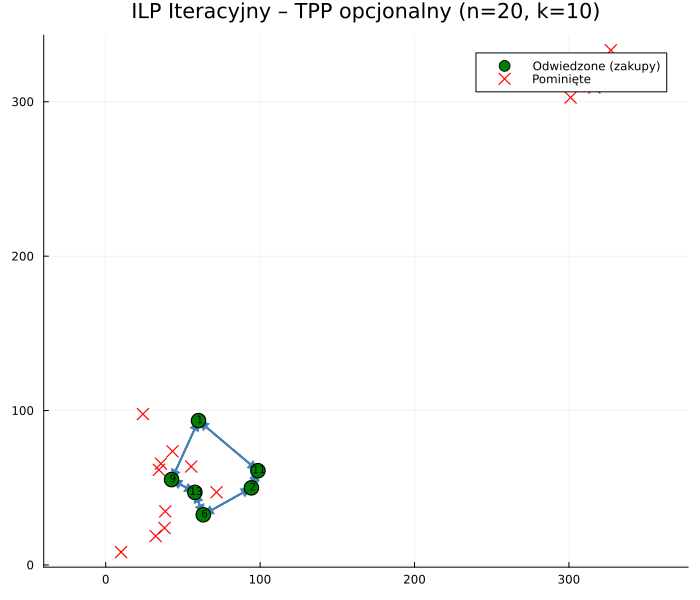

In [26]:
if is_solved_and_feasible(m_iter5)
    city_items_iter_plot = Dict{Int,Int}()
    for m in 1:k5
        ci = findfirst(JuMP.value.(m_iter5[:p])[m,:] .> 0.5)
        city_items_iter_plot[ci] = get(city_items_iter_plot, ci, 0) + 1
    end
    
    plt_iter5 = Plots.plot(
        title="ILP Iteracyjny – TPP opcjonalny (n=$n5, k=$k5)",
        legend=:topright, aspect_ratio=:equal, size=(700,600))
    
    for i in 1:n5, j in 1:n5
        if JuMP.value.(m_iter5[:x])[i,j] > 0.5
            Plots.plot!(plt_iter5, [X5[i],X5[j]], [Y5[i],Y5[j]];
                        color=:steelblue, lw=1.8, arrow=(:closed,0.4), label=false)
        end
    end
    
    visited_w  = [i for i in 1:n5 if yi5[i]>0.5 && get(city_items_iter_plot,i,0)>0]
    visited_no = [i for i in 1:n5 if yi5[i]>0.5 && get(city_items_iter_plot,i,0)==0]
    skipped_v  = [i for i in 1:n5 if yi5[i]<0.5]
    
    isempty(visited_w)  || Plots.scatter!(plt_iter5, X5[visited_w],  Y5[visited_w]; color=:green, markersize=8, label="Odwiedzone (zakupy)")
    isempty(visited_no) || Plots.scatter!(plt_iter5, X5[visited_no], Y5[visited_no]; color=:dodgerblue, markersize=7, label="Odwiedzone (depot)")
    isempty(skipped_v)  || Plots.scatter!(plt_iter5, X5[skipped_v],  Y5[skipped_v]; color=:red, markersize=6, markershape=:xcross, label="Pominięte")
    
    for i in [visited_w; visited_no]
        Plots.annotate!(plt_iter5, X5[i]+0.8, Y5[i]+0.8, Plots.text("$i", 7))
    end
    display(MIME("image/png"), plt_iter5)
end

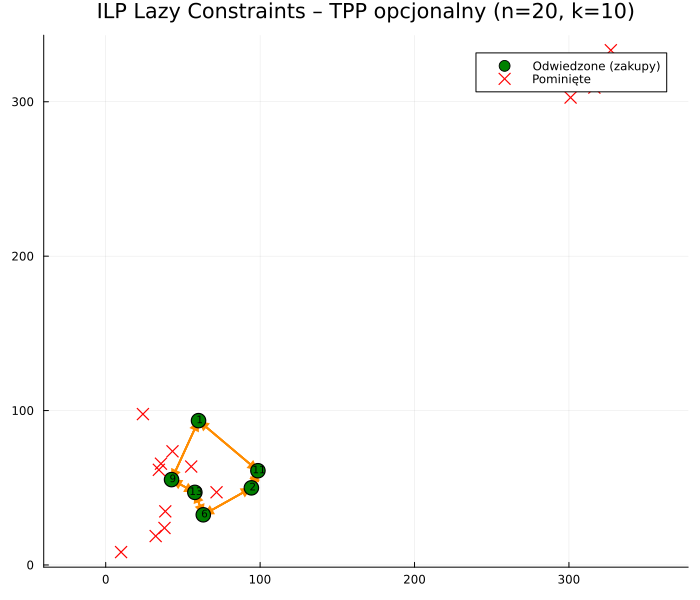

In [27]:
if is_solved_and_feasible(m_lazy5)
    city_items_lazy_plot = Dict{Int,Int}()
    for m in 1:k5
        ci = findfirst(JuMP.value.(m_lazy5[:p])[m,:] .> 0.5)
        city_items_lazy_plot[ci] = get(city_items_lazy_plot, ci, 0) + 1
    end
    
    plt_lazy5 = Plots.plot(
        title="ILP Lazy Constraints – TPP opcjonalny (n=$n5, k=$k5)",
        legend=:topright, aspect_ratio=:equal, size=(700,600))
    
    for i in 1:n5, j in 1:n5
        if JuMP.value.(m_lazy5[:x])[i,j] > 0.5
            Plots.plot!(plt_lazy5, [X5[i],X5[j]], [Y5[i],Y5[j]];
                        color=:darkorange, lw=1.8, arrow=(:closed,0.4), label=false)
        end
    end
    
    visited_lw  = [i for i in 1:n5 if yl5[i]>0.5 && get(city_items_lazy_plot,i,0)>0]
    visited_lno = [i for i in 1:n5 if yl5[i]>0.5 && get(city_items_lazy_plot,i,0)==0]
    skipped_lv  = [i for i in 1:n5 if yl5[i]<0.5]
    
    isempty(visited_lw)  || Plots.scatter!(plt_lazy5, X5[visited_lw],  Y5[visited_lw]; color=:green, markersize=8, label="Odwiedzone (zakupy)")
    isempty(visited_lno) || Plots.scatter!(plt_lazy5, X5[visited_lno], Y5[visited_lno]; color=:dodgerblue, markersize=7, label="Odwiedzone (depot)")
    isempty(skipped_lv)  || Plots.scatter!(plt_lazy5, X5[skipped_lv],  Y5[skipped_lv]; color=:red, markersize=6, markershape=:xcross, label="Pominięte")
    
    for i in [visited_lw; visited_lno]
        Plots.annotate!(plt_lazy5, X5[i]+0.8, Y5[i]+0.8, Plots.text("$i", 7))
    end
    display(MIME("image/png"), plt_lazy5)
end

## 5.6 Porównanie

In [28]:
if is_solved_and_feasible(m_iter5) && is_solved_and_feasible(m_lazy5)
    println("="^80)
    println("PORÓWNANIE – MODEL NIESKIEROWANY")
    println("="^80)
    @printf("%-22s | %12s | %12s | %12s | %8s\n", "Metoda", "Przejazd", "Zakupy", "Razem", "Czas [s]")
    println("-"^80)
    @printf("%-22s | %12.2f | %12.2f | %12.2f | %8.3f\n", "Iteracyjny", tv_iter, pv_iter, tv_iter+pv_iter, t_iter5)
    @printf("%-22s | %12.2f | %12.2f | %12.2f | %8.3f\n", "Lazy Constraints", tv_lazy, pv_lazy, tv_lazy+pv_lazy, t_lazy5)
    println("="^80)
end

PORÓWNANIE – MODEL NIESKIEROWANY
Metoda                 |     Przejazd |       Zakupy |        Razem | Czas [s]
--------------------------------------------------------------------------------
Iteracyjny             |       172.62 |       557.50 |       730.12 |    0.017
Lazy Constraints       |       172.62 |       557.50 |       730.12 |    0.373
